# Task 5: Domestic vs. International Search Bias — Query-Level Re-weighting

This notebook investigates a quality-of-service bias in the hotel ranking model: whether international searches receive worse ranking quality than domestic searches. It then applies an alternative mitigation technique: **query-level pre-processing re-weighting**.

The previous row-level re-weighting approach increased the weights of relevant hotels in international searches, but it worsened international performance. This notebook instead gives **all rows from international searches** a higher weight, preserving the within-search ranking structure while making international searches more influential during training.


## Cell 1: Imports and settings

In [1]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

RANDOM_STATE = 42
K = 5

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


## Cell 2: Load prepared Task 3 feature files

This assumes you already ran Task 3 and saved `train_features.parquet` and `val_features.parquet` in the `data/` folder.


In [2]:
train_feat = pd.read_parquet("data/train_features.parquet")
val_feat = pd.read_parquet("data/val_features.parquet")

print("Train features:", train_feat.shape)
print("Validation features:", val_feat.shape)

display(train_feat.head())


Train features: (3980039, 177)
Validation features: (978308, 177)


,srch_id,date_time,site_id,visitor_location_country_id,visitor_hist_starrating,visitor_hist_adr_usd,prop_country_id,prop_id,prop_starrating,prop_review_score,prop_brand_bool,prop_location_score1,prop_location_score2,prop_log_historical_price,position,price_usd,promotion_flag,srch_destination_id,srch_length_of_stay,srch_booking_window,srch_adults_count,srch_children_count,srch_room_count,srch_saturday_night_bool,srch_query_affinity_score,orig_destination_distance,random_bool,comp1_rate,comp1_inv,comp1_rate_percent_diff,comp2_rate,comp2_inv,comp2_rate_percent_diff,comp3_rate,comp3_inv,comp3_rate_percent_diff,comp4_rate,comp4_inv,comp4_rate_percent_diff,comp5_rate,comp5_inv,comp5_rate_percent_diff,comp6_rate,comp6_inv,comp6_rate_percent_diff,comp7_rate,comp7_inv,comp7_rate_percent_diff,comp8_rate,comp8_inv,comp8_rate_percent_diff,click_bool,gross_bookings_usd,booking_bool,relevance,visitor_hist_starrating_missing,visitor_hist_adr_usd_missing,srch_query_affinity_score_missing,orig_destination_distance_missing,prop_location_score2_missing,prop_review_score_missing,prop_review_score_is_zero,prop_starrating_is_zero,price_is_zero,price_below_1,price_below_10,price_usd_capped,price_usd_clipped,log_price_usd,log_price_usd_capped,log_price_usd_clipped,log_orig_destination_distance,total_guests,children_present,multi_room,domestic_search,log_booking_window,log_length_of_stay,last_minute_booking,long_booking_window,long_stay,is_4_star,is_5_star,high_review_score,search_month,search_quarter,search_dayofweek,search_hour,search_is_weekend,comp_rate_missing_count,comp_inv_missing_count,comp_pct_missing_count,comp_has_any_rate_data,comp_has_any_inv_data,comp_has_any_pct_data,comp_expedia_cheaper_count,comp_expedia_more_expensive_count,comp_same_price_count,comp_unavailable_count,comp_available_count,comp1_rate_missing,comp1_inv_missing,comp1_rate_percent_diff_missing,comp2_rate_missing,comp2_inv_missing,comp2_rate_percent_diff_missing,comp3_rate_missing,comp3_inv_missing,comp3_rate_percent_diff_missing,comp4_rate_missing,comp4_inv_missing,comp4_rate_percent_diff_missing,comp5_rate_missing,comp5_inv_missing,comp5_rate_percent_diff_missing,comp6_rate_missing,comp6_inv_missing,comp6_rate_percent_diff_missing,comp7_rate_missing,comp7_inv_missing,comp7_rate_percent_diff_missing,comp8_rate_missing,comp8_inv_missing,comp8_rate_percent_diff_missing,comp_no_rate_data_count,comp_no_inv_data_count,hotels_in_search,search_price_mean,search_price_median,search_price_min,search_price_max,price_diff_from_search_mean,price_diff_from_search_median,price_diff_from_search_min,price_ratio_to_search_mean,price_ratio_to_search_median,price_rank_in_search,price_pct_rank_in_search,search_log_price_mean,log_price_diff_from_search_mean,search_star_mean,search_star_max,star_diff_from_search_mean,star_diff_from_search_max,star_rank_in_search,star_pct_rank_in_search,search_review_mean,search_review_max,review_diff_from_search_mean,review_diff_from_search_max,review_rank_in_search,review_pct_rank_in_search,search_location1_mean,search_location2_mean,location1_diff_from_search_mean,location2_diff_from_search_mean,location2_rank_in_search,location2_pct_rank_in_search,search_promotion_rate,promotion_above_search_avg,prop_id_count,prop_id_mean_price,prop_id_median_price,prop_id_std_price,prop_id_mean_log_price,prop_id_mean_starrating,prop_id_mean_review_score,prop_id_mean_location_score1,prop_id_mean_location_score2,prop_id_mean_promotion_flag,dest_id_count,dest_id_mean_price,dest_id_median_price,dest_id_mean_starrating,dest_id_mean_review_score,dest_id_mean_location_score2,prop_dest_count
0,1,2013-04-04 08:32:15,12,187,-1.0,-1.0,219,893,3,3.5,1,2.83,0.0438,4.95,27,104.77,0,23246,1,0,4,0,1,1,-327.567505,392.559998,1,-2.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-2.0,-2.0,0.0,0.0,0.0,0.0,-2.0,-2.0,0.0,-2.0,-2.0,0.0,0.0,0.0,0.0,0,NaN,0,0,1,1,1,1,0,0,0,0,0,0,0,104.769997,104.769997,4.661267,4.661267,4.661267,5.975234,4,0,0,0,0.0,0.693147,1,0,0,0,0,0,4,2,3,8,0,4,4,8,1,1,0,0,0,4,0,4,1,1,1,0

## Cell 3: Define domestic vs. international search groups

A search is treated as domestic when the visitor country equals the hotel country. Otherwise it is treated as international/non-domestic.


In [3]:
train_feat["domestic_search"] = (
    train_feat["visitor_location_country_id"] == train_feat["prop_country_id"]
).astype(np.int8)

val_feat["domestic_search"] = (
    val_feat["visitor_location_country_id"] == val_feat["prop_country_id"]
).astype(np.int8)

train_feat["search_group"] = np.where(
    train_feat["domestic_search"] == 1,
    "Domestic searches",
    "International searches"
)

val_feat["search_group"] = np.where(
    val_feat["domestic_search"] == 1,
    "Domestic searches",
    "International searches"
)

search_group_summary = (
    val_feat.groupby("search_group")
    .agg(
        rows=("srch_id", "size"),
        searches=("srch_id", "nunique"),
        click_rate=("click_bool", "mean"),
        booking_rate=("booking_bool", "mean"),
        mean_relevance=("relevance", "mean"),
        mean_price=("price_usd", "mean"),
        mean_distance=("orig_destination_distance", "mean")
    )
    .reset_index()
)

search_group_summary["order"] = search_group_summary["search_group"].map({
    "Domestic searches": 0,
    "International searches": 1
})
search_group_summary = search_group_summary.sort_values("order").drop(columns="order")

display(search_group_summary)


,search_group,rows,searches,click_rate,booking_rate,mean_relevance,mean_price,mean_distance
0,Domestic searches,632156,25781,0.044557,0.029085,0.160895,252.778940,504.181030
1,International searches,346152,14284,0.046251,0.027693,0.157024,540.085716,1853.067993


## Cell 4: Build feature list

We exclude identifiers, target variables, and unavailable training-only variables from the model inputs.


In [4]:
NON_FEATURE_COLS = [
    "srch_id",
    "prop_id",
    "date_time",
    "click_bool",
    "booking_bool",
    "gross_bookings_usd",
    "position",
    "relevance",
    "search_group"
]

feature_cols = [
    col for col in train_feat.columns
    if col not in NON_FEATURE_COLS
    and pd.api.types.is_numeric_dtype(train_feat[col])
]

missing_in_val = set(feature_cols) - set(val_feat.columns)
extra_in_val = set(val_feat.columns) - set(train_feat.columns)

print("Number of model features:", len(feature_cols))
print("Missing in validation:", missing_in_val)
print("Extra columns in validation compared with train:", len(extra_in_val))
print("First 40 features:")
print(feature_cols[:40])


Number of model features: 169
Missing in validation: set()
Extra columns in validation compared with train: 0
First 40 features:
['site_id', 'visitor_location_country_id', 'visitor_hist_starrating', 'visitor_hist_adr_usd', 'prop_country_id', 'prop_starrating', 'prop_review_score', 'prop_brand_bool', 'prop_location_score1', 'prop_location_score2', 'prop_log_historical_price', 'price_usd', 'promotion_flag', 'srch_destination_id', 'srch_length_of_stay', 'srch_booking_window', 'srch_adults_count', 'srch_children_count', 'srch_room_count', 'srch_saturday_night_bool', 'srch_query_affinity_score', 'orig_destination_distance', 'random_bool', 'comp1_rate', 'comp1_inv', 'comp1_rate_percent_diff', 'comp2_rate', 'comp2_inv', 'comp2_rate_percent_diff', 'comp3_rate', 'comp3_inv', 'comp3_rate_percent_diff', 'comp4_rate', 'comp4_inv', 'comp4_rate_percent_diff', 'comp5_rate', 'comp5_inv', 'comp5_rate_percent_diff', 'comp6_rate', 'comp6_inv']


## Cell 5: Sort rows and create LightGBM matrices

LightGBM Ranker needs rows sorted by group so that the group-size arrays match the row order.


In [5]:
train_feat = train_feat.sort_values("srch_id").reset_index(drop=True)
val_feat = val_feat.sort_values("srch_id").reset_index(drop=True)

X_train = train_feat[feature_cols]
y_train = train_feat["relevance"].astype(int)
group_train = train_feat.groupby("srch_id").size().to_numpy()

X_val = val_feat[feature_cols]
y_val = val_feat["relevance"].astype(int)
group_val = val_feat.groupby("srch_id").size().to_numpy()

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("Number of train search groups:", len(group_train))
print("Number of validation search groups:", len(group_val))


X_train: (3980039, 169)
X_val: (978308, 169)
Number of train search groups: 159836
Number of validation search groups: 39959


## Cell 6: Evaluation functions

These functions compute NDCG@5 and domestic/international group metrics.


In [6]:
def dcg_at_k(relevances, k=5):
    relevances = np.asarray(relevances)[:k]
    if len(relevances) == 0:
        return 0.0
    discounts = np.log2(np.arange(2, len(relevances) + 2))
    gains = (2 ** relevances - 1)
    return float(np.sum(gains / discounts))


def ndcg_at_k_for_group(y_true, y_score, k=5):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    order = np.argsort(-y_score)
    ranked_relevance = y_true[order]
    ideal_order = np.argsort(-y_true)
    ideal_relevance = y_true[ideal_order]
    dcg = dcg_at_k(ranked_relevance, k=k)
    idcg = dcg_at_k(ideal_relevance, k=k)
    if idcg == 0:
        return 0.0
    return dcg / idcg


def mean_ndcg_at_k(df, y_true_col="relevance", y_score_col="score", group_col="srch_id", k=5):
    scores = []
    for _, group in df.groupby(group_col, sort=False):
        scores.append(
            ndcg_at_k_for_group(
                group[y_true_col].to_numpy(),
                group[y_score_col].to_numpy(),
                k=k
            )
        )
    return float(np.mean(scores))


def evaluate_domestic_international_bias(val_df, scores, model_name, k=5):
    eval_df = val_df[[
        "srch_id",
        "prop_id",
        "relevance",
        "booking_bool",
        "domestic_search",
        "search_group"
    ]].copy()
    eval_df["score"] = scores
    overall_ndcg = mean_ndcg_at_k(eval_df, k=k)

    rows = []
    for group_name, group_df in eval_df.groupby("search_group"):
        group_ndcg = mean_ndcg_at_k(group_df, k=k)
        booked_recall_hits = []
        booked_top1_hits = []
        booked_ranks = []
        booked_searches = 0

        for _, search_df in group_df.groupby("srch_id", sort=False):
            ranked = search_df.sort_values("score", ascending=False).reset_index(drop=True)
            booked_positions = np.where(ranked["booking_bool"].to_numpy() == 1)[0]
            if len(booked_positions) == 0:
                continue
            booked_searches += 1
            best_booked_position = int(booked_positions[0])
            booked_rank = best_booked_position + 1
            booked_ranks.append(booked_rank)
            booked_recall_hits.append(booked_rank <= k)
            booked_top1_hits.append(booked_rank == 1)

        rows.append({
            "group": group_name,
            "num_searches": group_df["srch_id"].nunique(),
            "num_booked_searches": booked_searches,
            "mean_ndcg_at_5": group_ndcg,
            "booked_recall_at_5": np.mean(booked_recall_hits) if booked_recall_hits else np.nan,
            "booked_top1_hit_rate": np.mean(booked_top1_hits) if booked_top1_hits else np.nan,
            "mean_booked_rank": np.mean(booked_ranks) if booked_ranks else np.nan
        })

    group_results = pd.DataFrame(rows)
    group_results["order"] = group_results["group"].map({
        "Domestic searches": 0,
        "International searches": 1
    })
    group_results = group_results.sort_values("order").drop(columns="order").reset_index(drop=True)

    domestic = group_results[group_results["group"] == "Domestic searches"].iloc[0]
    international = group_results[group_results["group"] == "International searches"].iloc[0]

    metrics = {
        "model": model_name,
        "overall_ndcg@5": overall_ndcg,
        "domestic_ndcg@5": domestic["mean_ndcg_at_5"],
        "international_ndcg@5": international["mean_ndcg_at_5"],
        "international_minus_domestic_ndcg@5": international["mean_ndcg_at_5"] - domestic["mean_ndcg_at_5"],
        "domestic_booked_recall@5": domestic["booked_recall_at_5"],
        "international_booked_recall@5": international["booked_recall_at_5"],
        "international_minus_domestic_recall@5": international["booked_recall_at_5"] - domestic["booked_recall_at_5"],
        "domestic_top1_hit_rate": domestic["booked_top1_hit_rate"],
        "international_top1_hit_rate": international["booked_top1_hit_rate"],
        "domestic_mean_booked_rank": domestic["mean_booked_rank"],
        "international_mean_booked_rank": international["mean_booked_rank"],
        "num_domestic_searches": int(domestic["num_searches"]),
        "num_international_searches": int(international["num_searches"]),
        "num_domestic_booked_searches": int(domestic["num_booked_searches"]),
        "num_international_booked_searches": int(international["num_booked_searches"])
    }
    return group_results, metrics


## Cell 7: Train the original LightGBM Ranker

This uses the best parameters from Task 4.


In [7]:
best_parameters = {
    "num_leaves": 383,
    "learning_rate": 0.02,
    "min_child_samples": 900,
    "reg_lambda": 10.0,
    "reg_alpha": 0.0,
    "subsample": 0.9,
    "colsample_bytree": 0.8,
    "n_estimators": 286
}

original_ranker = lgb.LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
    ndcg_eval_at=[5],
    boosting_type="gbdt",
    n_estimators=best_parameters["n_estimators"],
    learning_rate=best_parameters["learning_rate"],
    num_leaves=best_parameters["num_leaves"],
    max_depth=-1,
    min_child_samples=best_parameters["min_child_samples"],
    reg_lambda=best_parameters["reg_lambda"],
    reg_alpha=best_parameters["reg_alpha"],
    subsample=best_parameters["subsample"],
    colsample_bytree=best_parameters["colsample_bytree"],
    random_state=RANDOM_STATE,
    n_jobs=-1
)

original_ranker.fit(
    X_train,
    y_train,
    group=group_train,
    eval_set=[(X_val, y_val)],
    eval_group=[group_val],
    eval_at=[5],
    callbacks=[lgb.log_evaluation(period=100)]
)

print("Original model trained.")


/opt/anaconda3/envs/dmt-a2/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.496191 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16588
[LightGBM] [Info] Number of data points in the train set: 3980039, number of used features: 168
[100]	valid_0's ndcg@5: 0.383334
[200]	valid_0's ndcg@5: 0.385888
Original model trained.


## Cell 8: Evaluate original model for domestic vs. international bias

In [8]:
original_scores = original_ranker.predict(X_val)

original_group_results, original_metrics = evaluate_domestic_international_bias(
    val_feat,
    original_scores,
    model_name="Original LightGBM Ranker",
    k=K
)

display(original_group_results)
display(pd.DataFrame([original_metrics]).T.rename(columns={0: "value"}))


/opt/anaconda3/envs/dmt-a2/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


,group,num_searches,num_booked_searches,mean_ndcg_at_5,booked_recall_at_5,booked_top1_hit_rate,mean_booked_rank
0,Domestic searches,25781,18386,0.396130,0.606277,0.227075,6.458175
1,International searches,14284,9586,0.368685,0.572189,0.207699,6.991967


,value
model,Original LightGBM Ranker
overall_ndcg@5,0.387156
domestic_ndcg@5,0.39613
international_ndcg@5,0.368685
international_minus_domestic_ndcg@5,-0.027446
domestic_booked_recall@5,0.606277
international_booked_recall@5,0.572189
international_minus_domestic_recall@5,-0.034088
domestic_top1_hit_rate,0.227075
international_top1_hit_rate,0.207699


## Cell 9: Previous mitigation baseline — row-level re-weighting

This is included for comparison because this approach already showed poor results: it gives more weight only to relevant hotels in international searches.


In [9]:
row_weight = np.ones(len(train_feat))

row_weight[
    (train_feat["domestic_search"] == 0) &
    (train_feat["relevance"] > 0)
] = 1.25

row_weight[
    (train_feat["domestic_search"] == 0) &
    (train_feat["relevance"] == 5)
] = 1.50

row_weight_summary = pd.Series(row_weight).value_counts().sort_index().reset_index()
row_weight_summary.columns = ["weight", "count"]
row_weight_summary["share"] = row_weight_summary["count"] / len(row_weight)

display(row_weight_summary)


,weight,count,share
0,1.00,3913178,0.983201
1,1.25,28434,0.007144
2,1.50,38427,0.009655


## Cell 10: Train row-level re-weighted model

This model is mainly a comparison point against the new query-level mitigation.


In [10]:
row_weighted_ranker = lgb.LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
    ndcg_eval_at=[5],
    boosting_type="gbdt",
    n_estimators=best_parameters["n_estimators"],
    learning_rate=best_parameters["learning_rate"],
    num_leaves=best_parameters["num_leaves"],
    max_depth=-1,
    min_child_samples=best_parameters["min_child_samples"],
    reg_lambda=best_parameters["reg_lambda"],
    reg_alpha=best_parameters["reg_alpha"],
    subsample=best_parameters["subsample"],
    colsample_bytree=best_parameters["colsample_bytree"],
    random_state=RANDOM_STATE,
    n_jobs=-1
)

row_weighted_ranker.fit(
    X_train,
    y_train,
    group=group_train,
    sample_weight=row_weight,
    eval_set=[(X_val, y_val)],
    eval_group=[group_val],
    eval_at=[5],
    callbacks=[lgb.log_evaluation(period=100)]
)

print("Row-level international re-weighted model trained.")


/opt/anaconda3/envs/dmt-a2/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Info] Calculating query weights...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.519390 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16588
[LightGBM] [Info] Number of data points in the train set: 3980039, number of used features: 168
[100]	valid_0's ndcg@5: 0.38195
[200]	valid_0's ndcg@5: 0.382184
Row-level international re-weighted model trained.


## Cell 11: Evaluate row-level re-weighted model

In [11]:
row_weighted_scores = row_weighted_ranker.predict(X_val)

row_weighted_group_results, row_weighted_metrics = evaluate_domestic_international_bias(
    val_feat,
    row_weighted_scores,
    model_name="International row-weighted LightGBM Ranker",
    k=K
)

display(row_weighted_group_results)
display(pd.DataFrame([row_weighted_metrics]).T.rename(columns={0: "value"}))


/opt/anaconda3/envs/dmt-a2/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


,group,num_searches,num_booked_searches,mean_ndcg_at_5,booked_recall_at_5,booked_top1_hit_rate,mean_booked_rank
0,Domestic searches,25781,18386,0.392299,0.601327,0.222669,6.523822
1,International searches,14284,9586,0.357757,0.555706,0.199666,7.169727


,value
model,International row-weighted LightGBM Ranker
overall_ndcg@5,0.380616
domestic_ndcg@5,0.392299
international_ndcg@5,0.357757
international_minus_domestic_ndcg@5,-0.034541
domestic_booked_recall@5,0.601327
international_booked_recall@5,0.555706
international_minus_domestic_recall@5,-0.045621
domestic_top1_hit_rate,0.222669
international_top1_hit_rate,0.199666


## Cell 12: New mitigation — query-level re-weighting

Instead of changing only clicked/booked international hotel rows, this gives **all rows from international searches** the same higher weight. This makes international searches more influential during training while preserving the within-search ranking structure.


In [12]:
query_weight = np.ones(len(train_feat))

# Try 1.25 first. If you want a stronger intervention, change this to 1.50.
INTERNATIONAL_QUERY_WEIGHT = 1.25
query_weight[train_feat["domestic_search"] == 0] = INTERNATIONAL_QUERY_WEIGHT

query_weight_summary = pd.Series(query_weight).value_counts().sort_index().reset_index()
query_weight_summary.columns = ["weight", "count"]
query_weight_summary["share"] = query_weight_summary["count"] / len(query_weight)

display(query_weight_summary)


,weight,count,share
0,1.00,2531862,0.63614
1,1.25,1448177,0.36386


## Cell 13: Train query-level re-weighted model

In [13]:
query_weighted_ranker = lgb.LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
    ndcg_eval_at=[5],
    boosting_type="gbdt",
    n_estimators=best_parameters["n_estimators"],
    learning_rate=best_parameters["learning_rate"],
    num_leaves=best_parameters["num_leaves"],
    max_depth=-1,
    min_child_samples=best_parameters["min_child_samples"],
    reg_lambda=best_parameters["reg_lambda"],
    reg_alpha=best_parameters["reg_alpha"],
    subsample=best_parameters["subsample"],
    colsample_bytree=best_parameters["colsample_bytree"],
    random_state=RANDOM_STATE,
    n_jobs=-1
)

query_weighted_ranker.fit(
    X_train,
    y_train,
    group=group_train,
    sample_weight=query_weight,
    eval_set=[(X_val, y_val)],
    eval_group=[group_val],
    eval_at=[5],
    callbacks=[lgb.log_evaluation(period=100)]
)

print("Query-level international re-weighted model trained.")


/opt/anaconda3/envs/dmt-a2/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Info] Calculating query weights...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.494302 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16588
[LightGBM] [Info] Number of data points in the train set: 3980039, number of used features: 168
[100]	valid_0's ndcg@5: 0.383724
[200]	valid_0's ndcg@5: 0.385073
Query-level international re-weighted model trained.


## Cell 14: Evaluate query-level re-weighted model

In [14]:
query_weighted_scores = query_weighted_ranker.predict(X_val)

query_weighted_group_results, query_weighted_metrics = evaluate_domestic_international_bias(
    val_feat,
    query_weighted_scores,
    model_name="International query-weighted LightGBM Ranker",
    k=K
)

display(query_weighted_group_results)
display(pd.DataFrame([query_weighted_metrics]).T.rename(columns={0: "value"}))


/opt/anaconda3/envs/dmt-a2/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


,group,num_searches,num_booked_searches,mean_ndcg_at_5,booked_recall_at_5,booked_top1_hit_rate,mean_booked_rank
0,Domestic searches,25781,18386,0.393453,0.601490,0.224410,6.509246
1,International searches,14284,9586,0.365115,0.567286,0.204673,7.025349


,value
model,International query-weighted LightGBM Ranker
overall_ndcg@5,0.384129
domestic_ndcg@5,0.393453
international_ndcg@5,0.365115
international_minus_domestic_ndcg@5,-0.028338
domestic_booked_recall@5,0.60149
international_booked_recall@5,0.567286
international_minus_domestic_recall@5,-0.034205
domestic_top1_hit_rate,0.22441
international_top1_hit_rate,0.204673


## Cell 15: Compare all models

In [15]:
comparison_df = pd.DataFrame([
    original_metrics,
    row_weighted_metrics,
    query_weighted_metrics
])

comparison_display = comparison_df.copy()
numeric_cols = comparison_display.select_dtypes(include=["number"]).columns
comparison_display[numeric_cols] = comparison_display[numeric_cols].round(6)

display(comparison_display)
display(comparison_display.T)


,model,overall_ndcg@5,domestic_ndcg@5,international_ndcg@5,international_minus_domestic_ndcg@5,domestic_booked_recall@5,international_booked_recall@5,international_minus_domestic_recall@5,domestic_top1_hit_rate,international_top1_hit_rate,domestic_mean_booked_rank,international_mean_booked_rank,num_domestic_searches,num_international_searches,num_domestic_booked_searches,num_international_booked_searches
0,Original LightGBM Ranker,0.387156,0.396130,0.368685,-0.027446,0.606277,0.572189,-0.034088,0.227075,0.207699,6.458175,6.991967,25781,14284,18386,9586
1,International row-weighted LightGBM Ranker,0.380616,0.392299,0.357757,-0.034541,0.601327,0.555706,-0.045621,0.222669,0.199666,6.523822,7.169727,25781,14284,18386,9586
2,International query-weighted LightGBM Ranker,0.384129,0.393453,0.365115,-0.028338,0.601490,0.567286,-0.034205,0.224410,0.204673,6.509246,7.025349,25781,14284,18386,9586


,0,1,2
model,Original LightGBM Ranker,International row-weighted LightGBM Ranker,International query-weighted LightGBM Ranker
overall_ndcg@5,0.387156,0.380616,0.384129
domestic_ndcg@5,0.39613,0.392299,0.393453
international_ndcg@5,0.368685,0.357757,0.365115
international_minus_domestic_ndcg@5,-0.027446,-0.034541,-0.028338
domestic_booked_recall@5,0.606277,0.601327,0.60149
international_booked_recall@5,0.572189,0.555706,0.567286
international_minus_domestic_recall@5,-0.034088,-0.045621,-0.034205
domestic_top1_hit_rate,0.227075,0.222669,0.22441
international_top1_hit_rate,0.207699,0.199666,0.204673


## Cell 16: Compact report table

In [16]:
report_cols = [
    "model",
    "overall_ndcg@5",
    "domestic_ndcg@5",
    "international_ndcg@5",
    "international_minus_domestic_ndcg@5",
    "domestic_booked_recall@5",
    "international_booked_recall@5",
    "international_minus_domestic_recall@5",
    "domestic_top1_hit_rate",
    "international_top1_hit_rate",
    "domestic_mean_booked_rank",
    "international_mean_booked_rank"
]

report_table = comparison_display[report_cols].copy()
display(report_table)

report_table.to_csv("task5_domestic_international_query_weighting_results.csv", index=False)
print("Saved: task5_domestic_international_query_weighting_results.csv")


,model,overall_ndcg@5,domestic_ndcg@5,international_ndcg@5,international_minus_domestic_ndcg@5,domestic_booked_recall@5,international_booked_recall@5,international_minus_domestic_recall@5,domestic_top1_hit_rate,international_top1_hit_rate,domestic_mean_booked_rank,international_mean_booked_rank
0,Original LightGBM Ranker,0.387156,0.396130,0.368685,-0.027446,0.606277,0.572189,-0.034088,0.227075,0.207699,6.458175,6.991967
1,International row-weighted LightGBM Ranker,0.380616,0.392299,0.357757,-0.034541,0.601327,0.555706,-0.045621,0.222669,0.199666,6.523822,7.169727
2,International query-weighted LightGBM Ranker,0.384129,0.393453,0.365115,-0.028338,0.601490,0.567286,-0.034205,0.224410,0.204673,6.509246,7.025349


Saved: task5_domestic_international_query_weighting_results.csv


## Cell 17: Plot comparison of domestic vs. international metrics

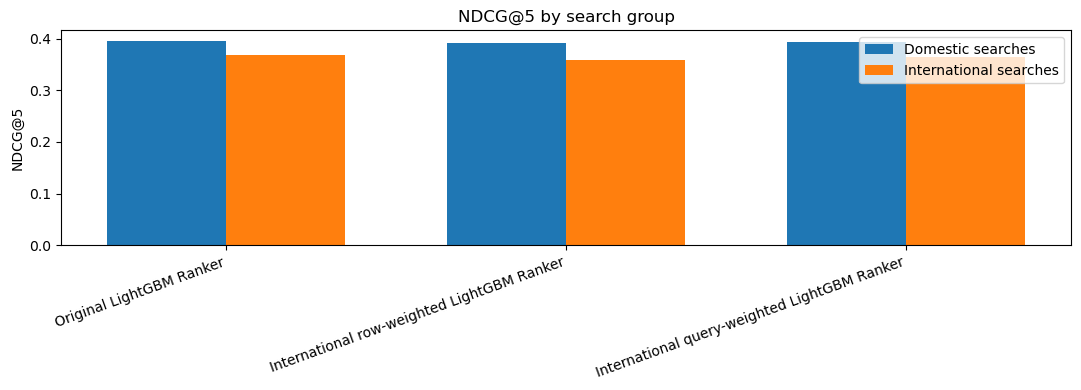

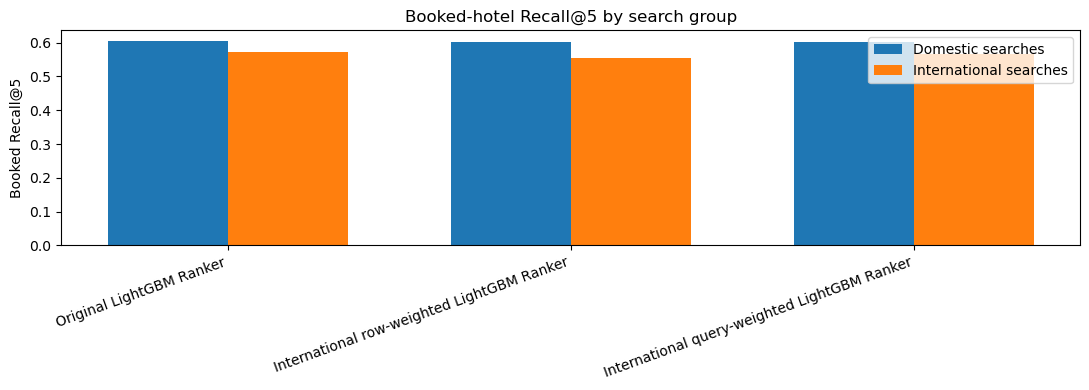

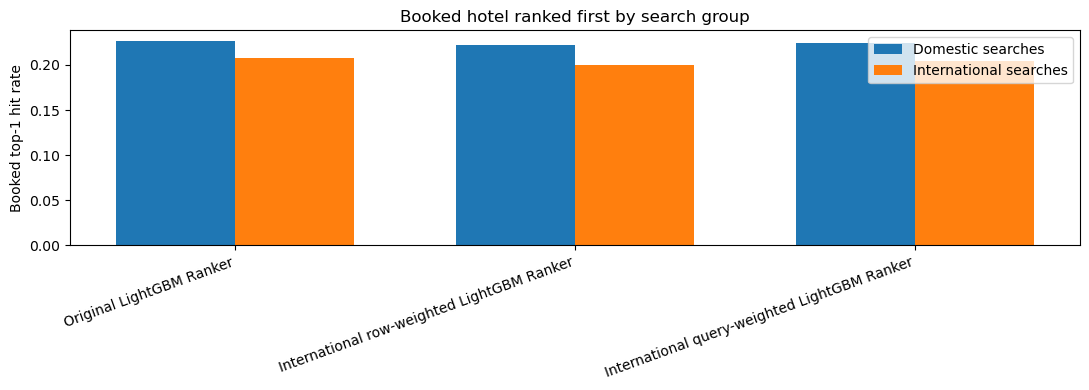

In [17]:
def plot_group_metric(metric_domestic, metric_international, ylabel, title):
    labels = comparison_display["model"].tolist()
    domestic_values = comparison_display[metric_domestic].to_numpy()
    international_values = comparison_display[metric_international].to_numpy()

    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(11, 4))
    plt.bar(x - width/2, domestic_values, width, label="Domestic searches")
    plt.bar(x + width/2, international_values, width, label="International searches")
    plt.xticks(x, labels, rotation=20, ha="right")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_group_metric(
    "domestic_ndcg@5",
    "international_ndcg@5",
    ylabel="NDCG@5",
    title="NDCG@5 by search group"
)

plot_group_metric(
    "domestic_booked_recall@5",
    "international_booked_recall@5",
    ylabel="Booked Recall@5",
    title="Booked-hotel Recall@5 by search group"
)

plot_group_metric(
    "domestic_top1_hit_rate",
    "international_top1_hit_rate",
    ylabel="Booked top-1 hit rate",
    title="Booked hotel ranked first by search group"
)


## Cell 18: Optional sensitivity test with stronger query-level weight

Run this only if the 1.25 query-level weight does not help enough. This tries a stronger query weight of 1.50 for all international-search rows.


In [21]:
# OPTIONAL: uncomment this cell if you want to test stronger query-level weighting.

strong_query_weight = np.ones(len(train_feat))
strong_query_weight[train_feat["domestic_search"] == 0] = 1.50

strong_query_weighted_ranker = lgb.LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
    ndcg_eval_at=[5],
    boosting_type="gbdt",
    n_estimators=best_parameters["n_estimators"],
    learning_rate=best_parameters["learning_rate"],
    num_leaves=best_parameters["num_leaves"],
    max_depth=-1,
    min_child_samples=best_parameters["min_child_samples"],
    reg_lambda=best_parameters["reg_lambda"],
    reg_alpha=best_parameters["reg_alpha"],
    subsample=best_parameters["subsample"],
    colsample_bytree=best_parameters["colsample_bytree"],
    random_state=RANDOM_STATE,
    n_jobs=-1
)

strong_query_weighted_ranker.fit(
    X_train,
    y_train,
    group=group_train,
    sample_weight=strong_query_weight,
    eval_set=[(X_val, y_val)],
    eval_group=[group_val],
    eval_at=[5],
    callbacks=[lgb.log_evaluation(period=100)]
)

strong_query_weighted_scores = strong_query_weighted_ranker.predict(X_val)

strong_group_results, strong_metrics = evaluate_domestic_international_bias(
    val_feat,
    strong_query_weighted_scores,
    model_name="International strong query-weighted LightGBM Ranker",
    k=K
)

display(strong_group_results)
display(pd.DataFrame([strong_metrics]).T.rename(columns={0: "value"}))


/opt/anaconda3/envs/dmt-a2/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Info] Calculating query weights...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.483904 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16588
[LightGBM] [Info] Number of data points in the train set: 3980039, number of used features: 168
[100]	valid_0's ndcg@5: 0.383584
[200]	valid_0's ndcg@5: 0.385297


/opt/anaconda3/envs/dmt-a2/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


,group,num_searches,num_booked_searches,mean_ndcg_at_5,booked_recall_at_5,booked_top1_hit_rate,mean_booked_rank
0,Domestic searches,25781,18386,0.393854,0.603666,0.225280,6.500435
1,International searches,14284,9586,0.366455,0.572084,0.203735,7.015856


,value
model,International strong query-weighted LightGBM R...
overall_ndcg@5,0.384896
domestic_ndcg@5,0.393854
international_ndcg@5,0.366455
international_minus_domestic_ndcg@5,-0.0274
domestic_booked_recall@5,0.603666
international_booked_recall@5,0.572084
international_minus_domestic_recall@5,-0.031582
domestic_top1_hit_rate,0.22528
international_top1_hit_rate,0.203735


## Cell 19: Short interpretation template

Use this after running the notebook and filling in the exact numbers from your output.


In [19]:
print("Interpretation template:")
print("""
The domestic/international analysis revealed a quality-of-service disparity.
In the original model, international searches had lower NDCG@5 and lower booked-hotel Recall@5 than domestic searches, indicating that the model ranked relevant hotels less effectively for international travellers.
We first tested row-level re-weighting of relevant international examples, but this did not improve the disparity.
We then tested query-level re-weighting, where all rows from international searches received a higher training weight.
This preserves the within-search ranking structure while increasing the influence of international searches during training.
The final decision depends on the validation trade-off: if query-level re-weighting improves international NDCG/Recall with only a small decrease in overall NDCG, it can be considered a useful mitigation; otherwise, the detected bias remains a deployment limitation requiring more careful future mitigation.
""")


Interpretation template:

The domestic/international analysis revealed a quality-of-service disparity.
In the original model, international searches had lower NDCG@5 and lower booked-hotel Recall@5 than domestic searches, indicating that the model ranked relevant hotels less effectively for international travellers.
We first tested row-level re-weighting of relevant international examples, but this did not improve the disparity.
We then tested query-level re-weighting, where all rows from international searches received a higher training weight.
This preserves the within-search ranking structure while increasing the influence of international searches during training.
The final decision depends on the validation trade-off: if query-level re-weighting improves international NDCG/Recall with only a small decrease in overall NDCG, it can be considered a useful mitigation; otherwise, the detected bias remains a deployment limitation requiring more careful future mitigation.

